<a href="https://colab.research.google.com/github/AJAXSINGH/DAA-PROJECT/blob/main/DAA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Shortest Paths from Vertex 0

  Vertex   Distance                           Path
-------------------------------------------------------
       0          0                              0
       1          3                    0 -> 2 -> 1
       2          1                         0 -> 2
       3          4               0 -> 2 -> 1 -> 3
       4          7          0 -> 2 -> 1 -> 3 -> 4
       5          9     0 -> 2 -> 1 -> 3 -> 4 -> 5


  Vertices       Time (ms)
------------------------------
        50          0.0335
       100          0.1380
       200          0.3509
       400          1.2568
       800          6.9614


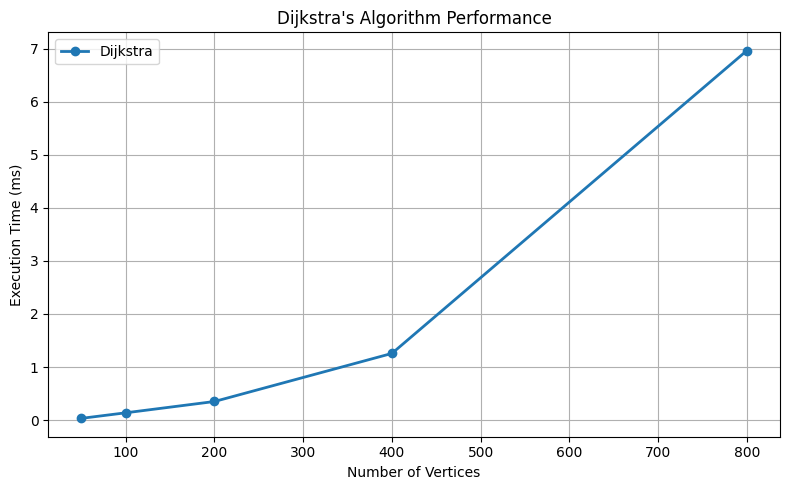

In [1]:
import heapq
import time
import random
import matplotlib.pyplot as plt


# ---------------- DIJKSTRA'S ALGORITHM ----------------

def dijkstra(graph, source):
    """
    Dijkstra's Algorithm using Min-Heap

    Time Complexity:
        O((V + E) log V)

    Space Complexity:
        O(V)
    """

    n = len(graph)

    dist = [float("inf")] * n
    prev = [None] * n

    dist[source] = 0

    pq = [(0, source)]          # (distance, vertex)
    visited = set()

    while pq:

        current_dist, u = heapq.heappop(pq)

        if u in visited:
            continue

        visited.add(u)

        for v, weight in graph[u]:

            if dist[u] + weight < dist[v]:
                dist[v] = dist[u] + weight
                prev[v] = u

                heapq.heappush(pq, (dist[v], v))

    return dist, prev


# ---------------- RECONSTRUCT SHORTEST PATH ----------------

def reconstruct_path(prev, source, target):

    path = []

    node = target

    while node is not None:
        path.append(node)
        node = prev[node]

    path.reverse()

    if path and path[0] == source:
        return path

    return []


# ---------------- SAMPLE GRAPH ----------------

graph = {
    0: [(1, 4), (2, 1)],
    1: [(3, 1)],
    2: [(1, 2), (3, 5)],
    3: [(4, 3)],
    4: [(5, 2)],
    5: []
}

source = 0

dist, prev = dijkstra(graph, source)

print(f"\nShortest Paths from Vertex {source}\n")

print(f"{'Vertex':>8} {'Distance':>10} {'Path':>30}")
print("-" * 55)

for vertex in range(len(graph)):

    path = reconstruct_path(prev, source, vertex)

    if path:
        path_string = " -> ".join(map(str, path))
    else:
        path_string = "No Path"

    distance = dist[vertex]

    if distance == float("inf"):
        distance = "INF"

    print(f"{vertex:>8} {str(distance):>10} {path_string:>30}")


# ---------------- PERFORMANCE ANALYSIS ----------------

sizes = [50, 100, 200, 400, 800]

execution_times = []

print("\n")
print(f"{'Vertices':>10} {'Time (ms)':>15}")
print("-" * 30)

for vertices in sizes:

    random_graph = {}

    for i in range(vertices):
        random_graph[i] = []

    # Create a random weighted graph
    for i in range(vertices):
        for j in range(i + 1, vertices):

            if random.random() < 0.05:
                weight = random.randint(1, 20)

                random_graph[i].append((j, weight))
                random_graph[j].append((i, weight))

    start = time.perf_counter()

    for _ in range(20):
        dijkstra(random_graph, 0)

    elapsed = (time.perf_counter() - start) / 20 * 1000

    execution_times.append(elapsed)

    print(f"{vertices:>10} {elapsed:>15.4f}")


# ---------------- PERFORMANCE GRAPH ----------------

plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    execution_times,
    marker="o",
    linewidth=2,
    label="Dijkstra"
)

plt.title("Dijkstra's Algorithm Performance")
plt.xlabel("Number of Vertices")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
